<a href="https://colab.research.google.com/github/mfletcher2021/DevopsBasics/blob/master/NBA_24_25_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing necessary packages

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state
from sklearn.linear_model import LinearRegression

Importing the dataset into Python

In [2]:
from google.colab import files
uploaded = files.upload()

Saving NBA analysis.csv to NBA analysis.csv


In [3]:
import io

NBA = pd.read_csv(io.BytesIO(uploaded['NBA analysis.csv']))

Reading the dataset

In [4]:
NBA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Season  300 non-null    object 
 1   Team    300 non-null    object 
 2   W       300 non-null    int64  
 3   L       300 non-null    int64  
 4   Finish  300 non-null    int64  
 5   Age     300 non-null    float64
 6   Ht.     300 non-null    object 
 7   Wt.     300 non-null    int64  
 8   G       300 non-null    int64  
 9   MP      300 non-null    int64  
 10  FG      300 non-null    int64  
 11  FGA     300 non-null    int64  
 12  FG%     300 non-null    float64
 13  3P      300 non-null    int64  
 14  3PA     300 non-null    int64  
 15  3P%     300 non-null    float64
 16  2P      300 non-null    int64  
 17  2PA     300 non-null    int64  
 18  2P%     300 non-null    float64
 19  FT      300 non-null    int64  
 20  FTA     300 non-null    int64  
 21  FT%     300 non-null    float64
 22  OR

In [5]:
NBA.head()

,Season,Team,W,L,Finish,Age,Ht.,Wt.,G,MP,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,2023-24,Atlanta Hawks,36,46,10,26.2,6'6,211,82,19855,...,0.797,1024,2639,3663,2180,615,369,1110,1522,9703
1,2022-23,Atlanta Hawks,41,41,7,24.9,6'6,210,82,19855,...,0.818,920,2719,3639,2049,580,401,1060,1541,9711
2,2021-22,Atlanta Hawks,43,39,8,26.1,6'6,211,82,19705,...,0.812,823,2783,3606,2017,587,348,972,1534,9343
3,2020-21,Atlanta Hawks,41,31,5,25.4,6'6,212,72,17405,...,0.812,760,2525,3285,1737,503,342,953,1392,8186
4,2019-20,Atlanta Hawks,20,47,14,24.1,6'6,213,67,16280,...,0.790,661,2237,2898,1605,523,341,1086,1548,7488


Linear Regression feature selection

In [7]:
X = NBA.drop(['Season', 'Team', 'W', 'Ht.'], axis=1)
y = NBA['W']

from sklearn.feature_selection import SelectKBest, f_regression
features = SelectKBest(score_func=f_regression, k=5)
features.fit(X, y)

selectedFeatures = X.columns[features.get_support()]
print(selectedFeatures)

Index(['L', 'Finish', 'Age', 'FG%', '3P%'], dtype='object')


Performing the train, test, split-linear regression style

In [14]:
X = NBA[['L', 'Finish', 'Age', 'FG%', '3P%']]
y = NBA['W']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

Making the model

In [19]:
NBAMODEL = LinearRegression()
NBAMODEL.fit(X_train, y_train)

LinearRegression()

In [27]:
yPredictions = NBAMODEL.predict(X_test)

yPredictions

array([53.20097648, 28.89541793, 52.26551381, 53.22220829, 35.90676716,
       32.15874993, 47.72090936, 48.32896277, 39.4193884 , 40.1548429 ,
       19.62678175, 48.3263792 , 32.13473281, 43.50887634, 43.85260484,
       52.79795145, 27.35822648, 40.23392095, 18.85423981, 61.69624816,
       51.59650403, 23.86311747, 56.18087097, 54.15867678, 49.75211403,
       46.90177259, 31.80109001, 46.82531833, 37.50563942, 32.19863141,
       52.41205133, 25.09011881, 48.94542256, 38.80244997, 24.80146638,
       42.50107728, 43.27320835, 37.45199938, 46.7795962 , 28.11289951,
       57.64388881, 29.35812466, 18.3222965 , 36.26677012, 20.56912227,
       22.15266241, 19.9955299 , 44.84930613, 45.14740453, 23.19471644,
       53.940611  , 26.0780373 , 27.88093669, 61.23347337, 52.99948229,
       34.66653881, 30.04421016, 27.21669768, 48.55215233, 47.11060905])

Finding the coefficients and intercepts of the regression model equation

In [22]:
NBAMODEL.coef_

array([ -0.4663858 ,  -1.30716212,   0.39700734,  34.1325687 ,
       -22.12258585])

In [13]:
NBAMODEL.intercept_

50.945769772855854

Evaluating model's accuracy

In [32]:
from sklearn.metrics import mean_absolute_percentage_error

mean_absolute_percentage_error(y_test,yPredictions)

0.09147159762376074

Viewing results of predictions on a scatterplot

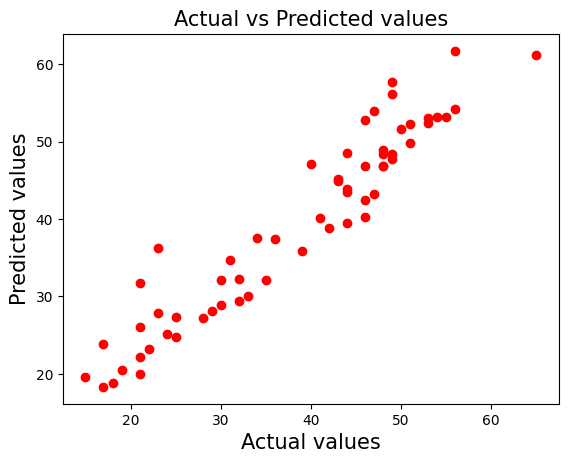

In [41]:
import matplotlib.pyplot as plt
plt.scatter(y_test, yPredictions, color="red")
plt.xlabel('Actual values', size=15)
plt.ylabel('Predicted values', size=15)
plt.title('Actual vs Predicted values', size=15)
plt.show()